In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2 as cv
import yaml
import xml.etree.ElementTree as ET

In [2]:
DATA_PATH = 'data'
CLASSIFICATION_PATH = os.path.join(DATA_PATH, 'Classification')
DETECTION_PATH = os.path.join(DATA_PATH, 'Detection')

In [3]:
images_list = os.listdir(os.path.join(CLASSIFICATION_PATH, 'JPEGImages'))

In [4]:
print(images_list[106])

levle0_196.jpg


In [5]:
with open(os.path.join('data', 'acne04v2-main', 'Acne04-v2_annotations.json'), 'r') as file:
    y_file = yaml.safe_load(file)
    print(type(y_file))

<class 'dict'>


In [6]:
df = pd.DataFrame(y_file['annotations'])

In [7]:
y_file['images'][0]

{'id': 0, 'file_name': 'levle3_116.jpg', 'height': 3456, 'width': 3112}

In [8]:
df[df['image_id'] == 0]

,id,image_id,radius,coordinates,class_name
0,0,0,25,"[2229, 168]",acne
1,1,0,22,"[2323, 273]",acne
2,2,0,20,"[2270, 260]",acne
3,3,0,35,"[2611, 378]",acne
4,4,0,27,"[2544, 311]",acne
...,...,...,...,...,...
85,85,0,28,"[2698, 608]",acne
86,86,0,26,"[2490, 635]",acne
87,87,0,26,"[2428, 537]",acne
88,88,0,24,"[2403, 563]",acne


In [9]:
idx = 0
num_add = 0
threshhold = 0.5

df_end = pd.DataFrame(columns=df.columns)
for num in range(len(pd.unique(df['image_id']))):
    print(f'Работа с изображением {num}')
    img = Image.open(os.path.join(CLASSIFICATION_PATH, 'JPEGImages', y_file['images'][num]['file_name'])).convert('RGB')
    img_arr = np.array(img)
    H, W, C = img_arr.shape
    mask_arr = np.zeros((H, W, C))

    annot_dict = {}
    image = y_file['images'][num]['file_name']
    name, _ = image.split('.')
    tree = ET.parse(os.path.join(DETECTION_PATH, 'VOC2007', 'Annotations', f'{name}.xml'))
    root = tree.getroot()
    columns = ['xmin', 'ymin', 'xmax', 'ymax']
    c=0
    objects = {}
    for item in root:
        if item.find('bndbox') != None:
            c+=1
            xmin = item.find('bndbox/xmin').text
            ymin = item.find('bndbox/ymin').text
            xmax = item.find('bndbox/xmax').text
            ymax = item.find('bndbox/ymax').text
            objects[c] = [xmin, ymin, xmax, ymax]
    annot_dict[name] = objects
    
    for item in annot_dict:
        for obj in annot_dict[item]:
            #print((annot_dict[item][obj][0], annot_dict[item][obj][3]), (annot_dict[item][obj][2], annot_dict[item][obj][1]))
            cv.rectangle(mask_arr, (int(annot_dict[item][obj][0]), int(annot_dict[item][obj][3])), (int(annot_dict[item][obj][2]), int(annot_dict[item][obj][1])), (255, 255, 255), -1)
    L = len(df[df['image_id'] == num]) + idx
    for n in range(idx, L):
        #print(n, num, L)
        radius = df['radius'][n]
        coords = df['coordinates'][n]
        xmin = int(coords[0] - radius)
        xmax = int(coords[0] + radius)
        ymin = int(coords[1] - radius)
        ymax = int(coords[1] + radius)
        roi = mask_arr[ymin:ymax, xmin:xmax, :]
        total_size = (ymax - ymin) * (xmax - xmin)
        orig_size = 0
        H, W, _ = roi.shape
        for y in range(H):
            for x in range(W):
                if (roi[y][x][0] == 255) and (roi[y][x][2] == 255) and (roi[y][x][1] == 255):
                    orig_size+=1
        #print(f'Площадь перекрытия объекта равна: {orig_size / total_size:.4f}')
        if orig_size / total_size <= threshhold:
            df_end.loc[num_add] = df.loc[n].copy()
            num_add+=1
    #print(num_add, idx, n)
    idx+=len(df[df['image_id'] == num])
    print(f'Было добавлено:{num_add} из {L}')

Работа с изображением 0
Было добавлено:32 из 90
Работа с изображением 1
Было добавлено:40 из 98
Работа с изображением 2
Было добавлено:46 из 105
Работа с изображением 3
Было добавлено:69 из 129
Работа с изображением 4
Было добавлено:86 из 151
Работа с изображением 5
Было добавлено:213 из 285
Работа с изображением 6
Было добавлено:292 из 377
Работа с изображением 7
Было добавлено:306 из 398
Работа с изображением 8
Было добавлено:331 из 430
Работа с изображением 9
Было добавлено:340 из 448
Работа с изображением 10
Было добавлено:360 из 481
Работа с изображением 11
Было добавлено:364 из 485
Работа с изображением 12
Было добавлено:390 из 521
Работа с изображением 13
Было добавлено:393 из 529
Работа с изображением 14
Было добавлено:408 из 570
Работа с изображением 15
Было добавлено:428 из 594
Работа с изображением 16
Было добавлено:484 из 674
Работа с изображением 17
Было добавлено:491 из 692
Работа с изображением 18
Было добавлено:499 из 701
Работа с изображением 19
Было добавлено:515 из 7

In [10]:
df.value_counts(['image_id'])

image_id
1189        434
216         232
1009        215
695         175
845         174
           ... 
495           1
524           1
663           1
897           1
943           1
Name: count, Length: 1204, dtype: int64

In [11]:
df_end.value_counts(['image_id'])

image_id
1189        278
216         168
959         134
845         133
1009        129
           ... 
1011          1
1083          1
1087          1
1096          1
1187          1
Name: count, Length: 1193, dtype: int64

In [11]:
df_images = pd.DataFrame(y_file['images'])

In [12]:
df_images

,id,file_name,height,width
0,0,levle3_116.jpg,3456,3112
1,1,levle0_196.jpg,3456,3112
2,2,levle1_360.jpg,3456,3112
3,3,levle0_137.jpg,3456,3112
4,4,levle1_230.jpg,3456,3112
...,...,...,...,...
1199,1199,levle0_181.jpg,3456,3112
1200,1200,levle1_500.jpg,3456,3112
1201,1201,levle1_330.jpg,3456,3112
1202,1202,levle0_241.jpg,3456,3112


In [13]:
df_end

,id,image_id,radius,coordinates,class_name
0,0,0,25,"[2229, 168]",acne
1,1,0,22,"[2323, 273]",acne
2,2,0,20,"[2270, 260]",acne
3,3,0,35,"[2611, 378]",acne
4,4,0,27,"[2544, 311]",acne
...,...,...,...,...,...
23636,32433,1202,26,"[1619, 696]",acne
23637,32434,1202,23,"[2088, 652]",acne
23638,32435,1202,16,"[821, 1978]",acne
23639,32438,1203,22,"[237, 2818]",acne


In [14]:
df

,id,image_id,radius,coordinates,class_name
0,0,0,25,"[2229, 168]",acne
1,1,0,22,"[2323, 273]",acne
2,2,0,20,"[2270, 260]",acne
3,3,0,35,"[2611, 378]",acne
4,4,0,27,"[2544, 311]",acne
...,...,...,...,...,...
32438,32438,1203,22,"[237, 2818]",acne
32439,32439,1203,41,"[1770, 795]",acne
32440,32440,1203,14,"[1731, 619]",acne
32441,32441,1203,12,"[1487, 2550]",acne


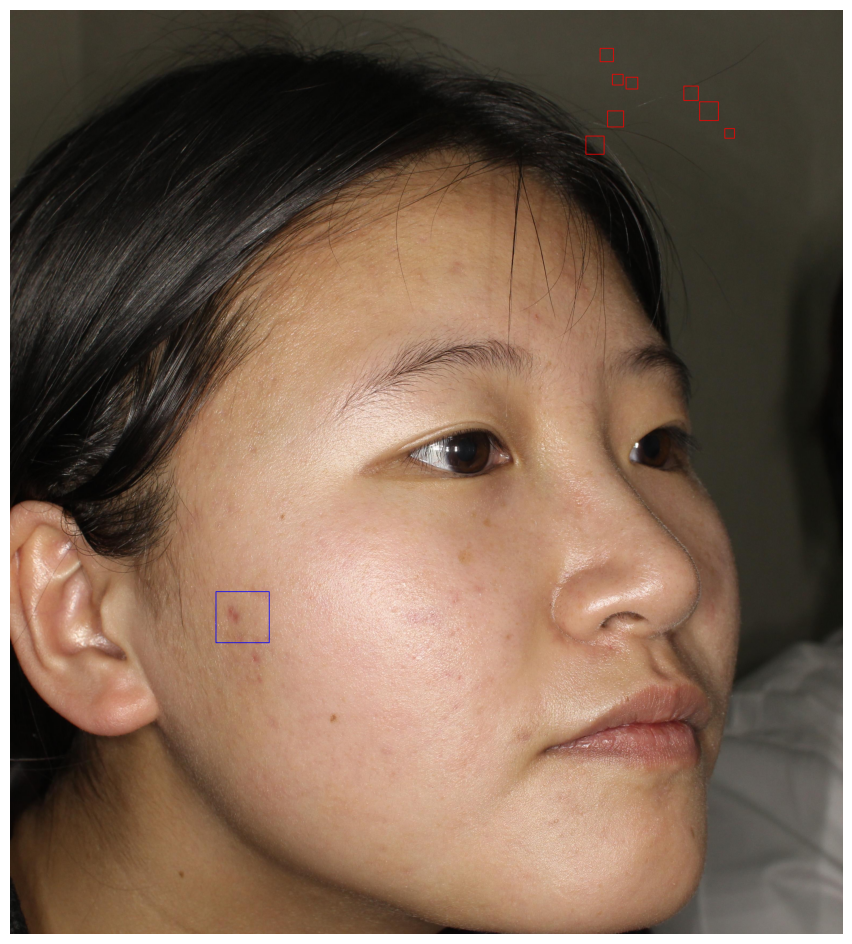

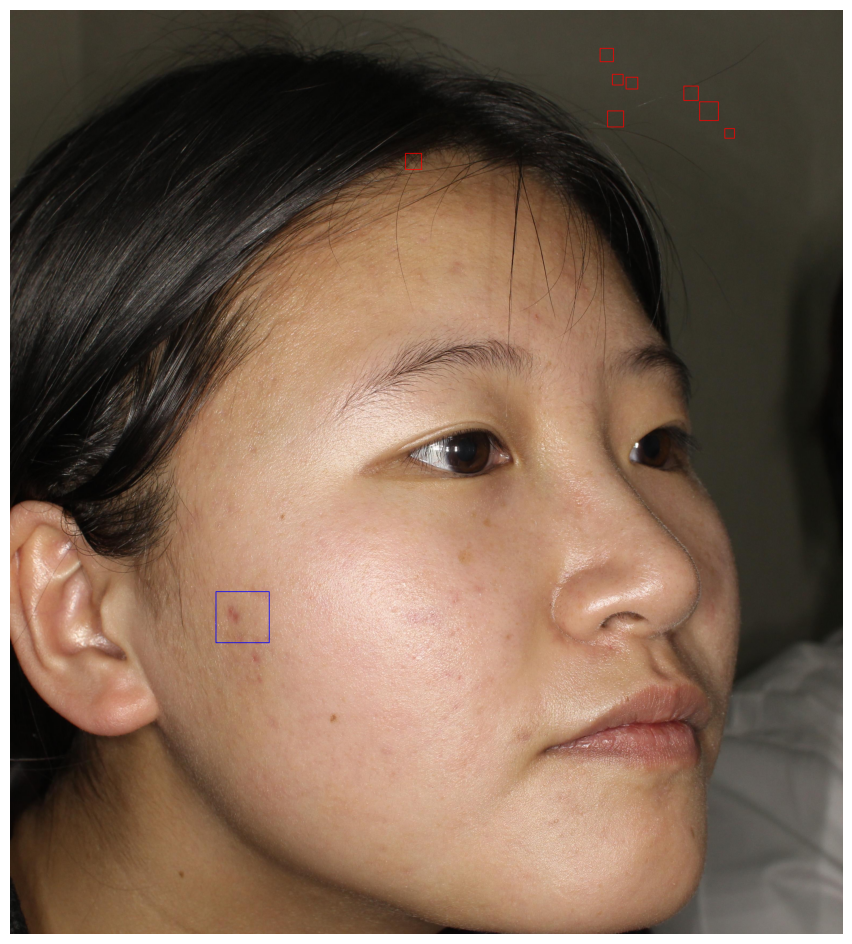

In [23]:
num = 1

img = Image.open(os.path.join(CLASSIFICATION_PATH, 'JPEGImages', y_file['images'][num]['file_name'])).convert('RGB')
img_arr = np.array(img)
after_prep_arr = np.array(img)

annot_dict = {}
image = y_file['images'][num]['file_name']
name, _ = image.split('.')
tree = ET.parse(os.path.join(DETECTION_PATH, 'VOC2007', 'Annotations', f'{name}.xml'))
root = tree.getroot()
columns = ['xmin', 'ymin', 'xmax', 'ymax']
c=0
objects = {}
for item in root:
    if item.find('bndbox') != None:
        c+=1
        xmin = item.find('bndbox/xmin').text
        ymin = item.find('bndbox/ymin').text
        xmax = item.find('bndbox/xmax').text
        ymax = item.find('bndbox/ymax').text
        objects[c] = [xmin, ymin, xmax, ymax]
annot_dict[name] = objects

for item in annot_dict:
    for obj in annot_dict[item]:
        cv.rectangle(img_arr, (int(annot_dict[item][obj][0]), int(annot_dict[item][obj][3])), (int(annot_dict[item][obj][2]), int(annot_dict[item][obj][1])), (0, 0, 255), 2)
        cv.rectangle(after_prep_arr, (int(annot_dict[item][obj][0]), int(annot_dict[item][obj][3])), (int(annot_dict[item][obj][2]), int(annot_dict[item][obj][1])), (0, 0, 255), 2)

for n in range(len(df[df['image_id'] == num])):
    slice = df[df['image_id'] == num]
    
    radius = df['radius'][n]
    coords = df['coordinates'][n]
    xmin = int(coords[0] - radius)
    xmax = int(coords[0] + radius)
    ymin = int(coords[1] - radius)
    ymax = int(coords[1] + radius)
    cv.rectangle(img_arr, (xmin, ymax), (xmax, ymin), (255, 0, 0), 2)

for n in range(len(df_end[df_end['image_id'] == num])):
    slice = df_end[df_end['image_id'] == num]
    
    radius = df_end['radius'][n]
    coords = df_end['coordinates'][n]
    xmin = int(coords[0] - radius)
    xmax = int(coords[0] + radius)
    ymin = int(coords[1] - radius)
    ymax = int(coords[1] + radius)
    cv.rectangle(after_prep_arr, (xmin, ymax), (xmax, ymin), (255, 0, 0), 2)

plt.figure(figsize=(12, 12))
plt.axis('off')
plt.imshow(img_arr)

plt.figure(figsize=(12, 12))
plt.axis('off')
plt.imshow(after_prep_arr)
plt.show()

In [85]:
col_list = ['id_images', 'filename', 'height', 'width']
df_images = pd.DataFrame(columns=col_list)
if not os.path.exists('data/csvs'):
    os.mkdir('data/csvs')

c = 0
for image in images_list:
    img = Image.open(os.path.join(CLASSIFICATION_PATH, 'JPEGImages', image)).convert('RGB')
    img_arr = np.array(img)
    H, W, C = img_arr.shape
    df_images.loc[c] = pd.Series([c, image, H, W], index = df_images.columns)
    c+=1

In [88]:
df_images

,id_images,filename,height,width
0,0,levle0_0.jpg,700,525
1,1,levle0_1.jpg,3456,3112
2,2,levle0_10.jpg,460,478
3,3,levle0_100.jpg,3456,3112
4,4,levle0_101.jpg,3456,3112
...,...,...,...,...
1452,1452,levle3_93.jpg,3264,4912
1453,1453,levle3_94.jpg,3264,4912
1454,1454,levle3_95.jpg,3264,4912
1455,1455,levle3_96.jpg,3264,4912


In [127]:
annot_columns = ['id_images', 'xmin', 'xmax', 'ymin', 'ymax', 'annot_V']
df_v1 = pd.DataFrame(columns=annot_columns)

counter = 0
for image in images_list:
    num = df_images[df_images['filename'] == image]['id_images']
    H = df_images[df_images['filename'] == image]['height']
    W = df_images[df_images['filename'] == image]['width']
    annot_dict = {}
    name, _ = image.split('.')
    tree = ET.parse(os.path.join(DETECTION_PATH, 'VOC2007', 'Annotations', f'{name}.xml'))
    root = tree.getroot()
    columns = ['xmin', 'ymin', 'xmax', 'ymax']
    for item in root:
        if item.find('bndbox') != None:
            xmin = float(item.find('bndbox/xmin').text) #/ W).values[0]
            ymin = float(item.find('bndbox/ymin').text) #/ H).values[0]
            xmax = float(item.find('bndbox/xmax').text) #/ W).values[0]
            ymax = float(item.find('bndbox/ymax').text) #/ H).values[0]
            df_v1.loc[counter] = pd.Series([num.values[0], xmin, xmax, ymin, ymax, 'V1'], index = df_v1.columns)
            counter+=1

In [93]:
df_v1

,id_images,xmin,xmax,ymin,ymax,annot_V
0,0,0.424762,0.478095,0.414286,0.437143,V1
1,0,0.413333,0.455238,0.357143,0.394286,V1
2,0,0.354286,0.398095,0.734286,0.765714,V1
3,1,0.126607,0.158419,0.269965,0.30787,V1
4,1,0.210154,0.242288,0.625,0.657986,V1
...,...,...,...,...,...,...
18978,1456,0.40513,0.426303,0.863358,0.908701,V1
18979,1456,0.461319,0.486564,0.772672,0.809436,V1
18980,1456,0.440147,0.47272,0.66973,0.713848,V1
18981,1456,0.463762,0.493893,0.610907,0.652574,V1


In [94]:
df_images_v2 = pd.DataFrame(y_file['images'])

In [95]:
df_images_v2

,id,file_name,height,width
0,0,levle3_116.jpg,3456,3112
1,1,levle0_196.jpg,3456,3112
2,2,levle1_360.jpg,3456,3112
3,3,levle0_137.jpg,3456,3112
4,4,levle1_230.jpg,3456,3112
...,...,...,...,...
1199,1199,levle0_181.jpg,3456,3112
1200,1200,levle1_500.jpg,3456,3112
1201,1201,levle1_330.jpg,3456,3112
1202,1202,levle0_241.jpg,3456,3112


In [96]:
df_end = df_end.drop('class_name', axis = 1)
df_end = df_end.drop('id', axis = 1)

KeyError: "['class_name'] not found in axis"

In [97]:
df_end

,image_id,radius,coordinates
0,0,25,"[2229, 168]"
1,0,22,"[2323, 273]"
2,0,20,"[2270, 260]"
3,0,35,"[2611, 378]"
4,0,27,"[2544, 311]"
...,...,...,...
23636,1202,26,"[1619, 696]"
23637,1202,23,"[2088, 652]"
23638,1202,16,"[821, 1978]"
23639,1203,22,"[237, 2818]"


In [128]:
df_v2 = pd.DataFrame(columns=annot_columns)
c = len(df_v1)
for name in df_images['filename']:
    id = df_images_v2[df_images_v2['file_name'] == name]['id']
    id_v1 = df_images[df_images['filename'] == name]['id_images']

    if id.values.size != 0:
        id = id.values[0]
        id_v1 = id_v1.values[0]
        fragment = df_end[df_end['image_id'] == id]
        H = df_images[df_images['id_images'] == id_v1]['height'].values[0]
        W = df_images[df_images['id_images'] == id_v1]['width'].values[0]
        for n in range(len(fragment)):
            row = fragment.iloc[n]
            radius = row['radius']
            coords = row['coordinates']

            xmin = float(coords[0] - radius) #/ W
            xmax = float(coords[0] + radius) #/ W
            ymin = float(coords[1] - radius) #/ H
            ymax = float(coords[1] + radius) #/ H

            df_v2.loc[c] = pd.Series([id_v1, xmin, xmax, ymin, ymax, 'V2'], index = df_v2.columns)
            c+=1
        
df_FINAL = pd.concat((df_v1, df_v2))

In [129]:
df_FINAL.head(50)

,id_images,xmin,xmax,ymin,ymax,annot_V
0,0,223.0,251.0,290.0,306.0,V1
1,0,217.0,239.0,250.0,276.0,V1
2,0,186.0,209.0,514.0,536.0,V1
3,1,394.0,493.0,933.0,1064.0,V1
4,1,654.0,754.0,2160.0,2274.0,V1
5,1,930.0,1099.0,3079.0,3179.0,V1
6,2,357.0,373.0,92.0,119.0,V1
7,2,394.0,424.0,114.0,139.0,V1
8,2,314.0,336.0,174.0,194.0,V1
9,2,316.0,342.0,246.0,276.0,V1


In [120]:
df_FINAL.to_csv('annot.csv')

In [119]:
df_FINAL.iloc[38550]

id_images         1168
xmin         72.775707
xmax         74.607969
ymin         71.463542
ymax         73.113426
annot_V             V2
Name: 38550, dtype: object

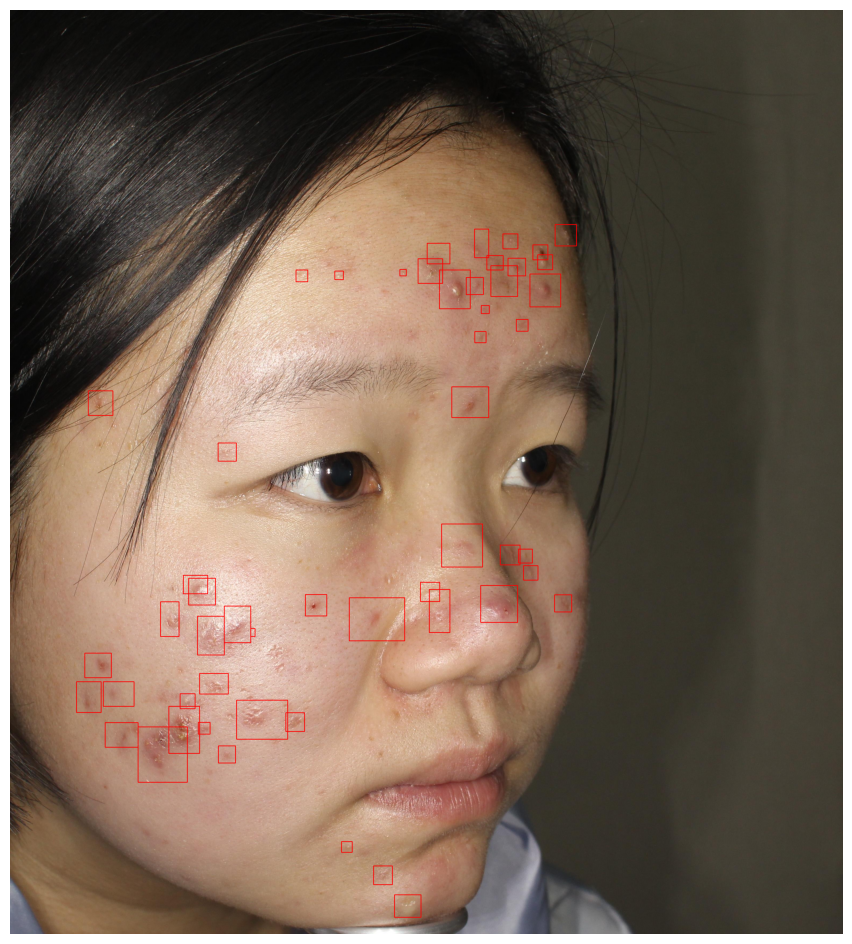

In [138]:
df_sorted = df_FINAL.sort_values(by = 'id_images', )

num = 1173
frag = df_sorted[df_sorted['id_images'] == num]
                 
img = Image.open(os.path.join(CLASSIFICATION_PATH, 'JPEGImages', df_images[df_images['id_images'] == num].values[0][1])).convert('RGB')
H = df_images[df_images['id_images'] == num].values[0][2]
W = df_images[df_images['id_images'] == num].values[0][3]
img_arr = np.array(img)

for i in range(len(df_sorted[df_sorted['id_images'] == num])):
    row = frag.iloc[i]
    xmin = int(row['xmin']) #* H
    xmax = int(row['xmax']) #* H
    ymin = int(row['ymin']) #* W
    ymax = int(row['ymax']) #* W
    cv.rectangle(img_arr, (xmin, ymax), (xmax, ymin), (255, 0, 0), 2)

plt.figure(figsize=(12, 12))
plt.axis('off')
plt.imshow(img_arr)

In [126]:
H, W

(3456, 3112)